<a href="https://colab.research.google.com/github/Tunz-tech/Bridging-the-Tap/blob/main/Bridging%20the%20Tap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. READ THE DATA
file_path = 'Estimates of the use of water (2000-2020).csv'

# For now, let's load the sheet. (We assume the data is in the first sheet)
df = pd.read_csv(file_path)

print("--- Data Successfully Loaded ---")
print(f"Total rows: {df.shape[0]}")

# 3. PREVIEW THE DATA
df.head()

--- Data Successfully Loaded ---
Total rows: 464


,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u
0,Croatia,2020,4105.268066,57.552998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,0.0,0.000000,0
1,Croatia,2015,4232.874023,56.155003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,0.0,0.000000,0
2,Argentina,2020,45195.77734,92.111000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.790421,0.0,0.209579,0
3,Greece,2015,10659.7373,78.046005,100.000005,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.000000,0.0,0.000000,0
4,Andorra,2020,77.26499939,87.916000,100.000004,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.000000,0.0,0.000000,0


In [ ]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
name,0
year,0
pop_n,0
pop_u,0
wat_bas_n,3
wat_lim_n,3
wat_unimp_n,3
wat_sur_n,18
wat_bas_r,125
wat_lim_r,125


In [ ]:
# 2. MERGE DATA WITH REGIONS
regions_df = pd.read_csv('Regions.csv')
merged_df = pd.merge(df, regions_df, on='name', how='left')

print("--- Data Merged with Regions ---")
print(f"Total rows after merge: {merged_df.shape[0]}")
print("Columns in merged_df:", merged_df.columns.tolist())
merged_df.head()

--- Data Merged with Regions ---
Total rows after merge: 464
Columns in merged_df: ['name', 'year', 'pop_n', 'pop_u', 'wat_bas_n', 'wat_lim_n', 'wat_unimp_n', 'wat_sur_n', 'wat_bas_r', 'wat_lim_r', 'wat_unimp_r', 'wat_sur_r', 'wat_bas_u', 'wat_lim_u', 'wat_unimp_u', 'wat_sur_u', 'region']


,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u,region
0,Croatia,2020,4105.268066,57.552998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,0.0,0.000000,0,Europe & Central Asia
1,Croatia,2015,4232.874023,56.155003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,0.0,0.000000,0,Europe & Central Asia
2,Argentina,2020,45195.77734,92.111000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.790421,0.0,0.209579,0,Latin America & Caribbean
3,Greece,2015,10659.7373,78.046005,100.000005,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.000000,0.0,0.000000,0,Europe & Central Asia
4,Andorra,2020,77.26499939,87.916000,100.000004,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.000000,0.0,0.000000,0,Europe & Central Asia


In [ ]:
# Incorporate data from 'Estimates on the use of water (2020).csv'

# 1. Load the 2020 specific data (using semicolon as delimiter)
df_2020_new = pd.read_csv('/content/Estimates on the use of water (2020).csv', sep=';')

# 2. Merge the 2020 data with regions_df to get the 'region' column
df_2020_new_merged = pd.merge(df_2020_new, regions_df, on='name', how='left')

# 3. Remove 2020 data from the existing merged_df to avoid duplicates
#    Assuming the new 2020 file is more comprehensive or updated for that year
merged_df_without_2020 = merged_df[merged_df['year'] != 2020]

# 4. Concatenate the historical data (without its 2020 entries) with the new 2020 data
merged_df = pd.concat([merged_df_without_2020, df_2020_new_merged], ignore_index=True)

print("\n--- Merged with additional 2020 data ---")
print(f"Total rows after final merge: {merged_df.shape[0]}")
print("Columns in updated merged_df:", merged_df.columns.tolist())
display(merged_df.head())


--- Merged with additional 2020 data ---
Total rows after final merge: 676
Columns in updated merged_df: ['name', 'year', 'pop_n', 'pop_u', 'wat_bas_n', 'wat_lim_n', 'wat_unimp_n', 'wat_sur_n', 'wat_bas_r', 'wat_lim_r', 'wat_unimp_r', 'wat_sur_r', 'wat_bas_u', 'wat_lim_u', 'wat_unimp_u', 'wat_sur_u', 'region', 'income_group']


,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u,region,income_group
0,Croatia,2015.0,4232.874023,56.155003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,0.0,0.0,0,Europe & Central Asia,NaN
1,Greece,2015.0,10659.7373,78.046005,100.000005,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0,Europe & Central Asia,NaN
2,Germany,2015.0,81787.41406,77.200005,100.000002,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0,Europe & Central Asia,NaN
3,Iceland,2015.0,330.2369995,93.699997,100.000002,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0,Europe & Central Asia,NaN
4,Israel,2015.0,7978.496094,92.179001,100.000001,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0,Europe & Central Asia,NaN


The `merged_df` now includes data from all three CSV files, with the `Estimates on the use of water (2020).csv` replacing any 2020 data that might have been present in the original `Estimates of the use of water (2000-2020).csv`.

In [ ]:
import pandas as pd
import numpy as np

# Let's assume your merged dataset from the previous step is named 'merged_df'
# For safety, let's filter the data to just look at the National Basic Water metric ('wat_bas_n')
# You can easily swap this out for 'wat_bas_r' (Rural) or 'wat_bas_u' (Urban) later!

# Convert 'year' column to integer type to ensure consistent filtering
# Handle potential NaN values by converting them to int after filling with a placeholder or dropping
# For this case, we will drop NaN years as they are not relevant for 2000 or 2020 analysis
merged_df_cleaned = merged_df.dropna(subset=['year']).copy()
merged_df_cleaned['year'] = merged_df_cleaned['year'].astype(int)

# 1. Pivot the data so we have 2000 and 2020 values side-by-side for each country
# Filter for the relevant years and use pivot_table to handle potential missing years gracefully
pivot_df = merged_df_cleaned[merged_df_cleaned['year'].isin([2000, 2020])].pivot_table(
    index=['name', 'region'], # Keeps country name and its region
    columns='year',
    values='wat_bas_n',
    aggfunc='mean' # Aggregate duplicate entries by taking the mean
).reset_index()

# Rename the columns so they are easy to read and ensure both year columns exist
pivot_df.rename(columns={'name': 'Country', 'region': 'Region', 2000: 'Water_2000', 2020: 'Water_2020'}, inplace=True)

# Ensure 'Water_2000' and 'Water_2020' columns exist, adding them with NaN if missing
if 'Water_2000' not in pivot_df.columns:
    pivot_df['Water_2000'] = np.nan
if 'Water_2020' not in pivot_df.columns:
    pivot_df['Water_2020'] = np.nan

# Reorder columns to ensure consistency after potential addition of missing year columns
pivot_df = pivot_df[['Country', 'Region', 'Water_2000', 'Water_2020']]

# Drop countries that don't have data for BOTH 2000 and 2020 to ensure clean math
predict_df = pivot_df.dropna(subset=['Water_2000', 'Water_2020']).copy()

# 2. RUN THE VELOCITY & PROJECTION MATH
# Calculate historical annual growth rate
predict_df['Annual_Velocity'] = (predict_df['Water_2020'] - predict_df['Water_2000']) / 20

# Project to 2030 (10 years forward from 2020)
predict_df['Projected_2030'] = predict_df['Water_2020'] + (predict_df['Annual_Velocity'] * 10)

# Cap the projection at 100% (you can't have more than 100% of a population with water)
predict_df['Projected_2030'] = predict_df['Projected_2030'].clip(upper=100)

# Calculate the gap remaining to hit the 100% SDG Target
predict_df['SDG_2030_Gap'] = 100 - predict_df['Projected_2030']

# 3. CLASSIFY THE COUNTRIES FOR BI/DASHBOARD REPORTING
def classify_trajectory(row):
    if row['Water_2020'] >= 99:
        return 'Achieved Universal Access'
    elif row['Projected_2030'] >= 99:
        return 'On Track for 2030'
    elif row['Annual_Velocity'] <= 0:
        return 'Stagnating or Regressing'
    else:
        return 'Off Track (Too Slow)'

predict_df['SDG_Status'] = predict_df.apply(classify_trajectory, axis=1)

print("--- Predictive Velocity Pipeline Complete ---")
print(predict_df['SDG_Status'].value_counts())

# Show the top 5 countries falling furthest behind (highest gap)
print("\n🔥 Countries with the Largest Projected 2030 Gaps:")
display(predict_df.sort_values(by='SDG_2030_Gap', ascending=False).head(5))

--- Predictive Velocity Pipeline Complete ---
Series([], Name: count, dtype: int64)

🔥 Countries with the Largest Projected 2030 Gaps:


year,Country,Region,Water_2000,Water_2020,Annual_Velocity,Projected_2030,SDG_2030_Gap,SDG_Status


In [ ]:
import pandas as pd
import numpy as np

# Let's clean up any NaN values specifically in our target column before finding years
# We will use 'wat_bas_n' (National Basic Water), but this code works for any column!
metric = 'wat_bas_n'
valid_data = merged_df.dropna(subset=[metric]).copy()

# 1. For each country, find the EARLIEST available year and its value
earliest_idx = valid_data.groupby('name')['year'].idxmin()
earliest_df = valid_data.loc[earliest_idx, ['name', 'region', 'year', metric]].rename(
    columns={'year': 'Start_Year', metric: 'Start_Value'}
)

# 2. For each country, find the LATEST available year and its value
latest_idx = valid_data.groupby('name')['year'].idxmax()
latest_df = valid_data.loc[latest_idx, ['name', 'year', metric]].rename(
    columns={'year': 'End_Year', metric: 'End_Value'}
)

# 3. Combine them together
predict_df = pd.merge(earliest_df, latest_df, on='name', how='inner')

# Filter out countries that only have 1 single year of data total (we need a timeline to calculate velocity)
predict_df = predict_df[predict_df['Start_Year'] != predict_df['End_Year']].copy()

# 4. DYNAMIC VELOCITY MATH
# (End Value - Start Value) divided by the actual number of years that passed
predict_df['Years_Passed'] = predict_df['End_Year'] - predict_df['Start_Year']
predict_df['Annual_Velocity'] = (predict_df['End_Value'] - predict_df['Start_Value']) / predict_df['Years_Passed']

# Project to 2030 based on where they left off at 'End_Value'
predict_df['Years_To_2030'] = 2030 - predict_df['End_Year']
predict_df['Projected_2030'] = predict_df['End_Value'] + (predict_df['Annual_Velocity'] * predict_df['Years_To_2030'])
predict_df['Projected_2030'] = predict_df['Projected_2030'].clip(lower=0, upper=100)

# Calculate Target Gap
predict_df['SDG_2030_Gap'] = 100 - predict_df['Projected_2030']

# 5. CLASSIFICATION SYSTEM
def classify_trajectory(row):
    if row['End_Value'] >= 99:
        return 'Achieved Universal Access'
    elif row['Projected_2030'] >= 99:
        return 'On Track for 2030'
    elif row['Annual_Velocity'] <= 0:
        return 'Stagnating or Regressing'
    else:
        return 'Off Track (Too Slow)'

predict_df['SDG_Status'] = predict_df.apply(classify_trajectory, axis=1)

print("--- Dynamic Predictive Velocity Pipeline Complete ---")
print(f"Successfully processed {predict_df.shape[0]} countries!")
print("\nBreakdown of Global SDG Statuses:")
print(predict_df['SDG_Status'].value_counts())

# Preview your top insights
display(predict_df[['name', 'region', 'Start_Year', 'End_Year', 'Annual_Velocity', 'SDG_Status']].head(10))

--- Dynamic Predictive Velocity Pipeline Complete ---
Successfully processed 18 countries!

Breakdown of Global SDG Statuses:
SDG_Status
Stagnating or Regressing     13
Off Track (Too Slow)          4
Achieved Universal Access     1
Name: count, dtype: int64


,name,region,Start_Year,End_Year,Annual_Velocity,SDG_Status
6,Anguilla,Latin America & Caribbean,2015.0,2017.0,0.000000,Stagnating or Regressing
7,Antigua and Barbuda,Latin America & Caribbean,2015.0,2017.0,0.000000,Stagnating or Regressing
10,Aruba,Latin America & Caribbean,2015.0,2016.0,0.000000,Stagnating or Regressing
14,Bahamas,Latin America & Caribbean,2015.0,2019.0,0.000000,Stagnating or Regressing
37,Cayman Islands,Latin America & Caribbean,2015.0,2016.0,0.000000,Stagnating or Regressing
40,Channel Islands,Europe & Central Asia,2015.0,2017.0,0.000000,Stagnating or Regressing
46,Comoros,Sub-Saharan Africa,2015.0,2019.0,0.019624,Off Track (Too Slow)
51,Curaçao,Latin America & Caribbean,2015.0,2017.0,0.000000,Achieved Universal Access
59,Dominica,Latin America & Caribbean,2015.0,2017.0,0.000000,Stagnating or Regressing
64,Equatorial Guinea,Sub-Saharan Africa,2015.0,2017.0,0.243607,Off Track (Too Slow)


In [ ]:
# Let's count how many non-missing values exist for EVERY water column in your dataset
water_cols = [col for col in merged_df.columns if col.startswith('wat_')]
print("--- Actual Data Rows Available Per Metric ---")
print(merged_df[water_cols].notna().sum())

--- Actual Data Rows Available Per Metric ---
wat_bas_n      249
wat_lim_n      249
wat_unimp_n    249
wat_sur_n      241
wat_bas_r      174
wat_lim_r      174
wat_unimp_r    174
wat_sur_r      170
wat_bas_u      188
wat_lim_u      188
wat_unimp_u    188
wat_sur_u      187
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# Ensure we are using the column with the most data
metric = 'wat_bas_n'
valid_data = merged_df.dropna(subset=[metric]).copy()

# Ensure 'year' is treated as an integer
valid_data['year'] = valid_data['year'].astype(int)

# 1. Group by country and get the absolute earliest and latest rows with valid data
summary_data = []

for country, group in valid_data.groupby('name'):
    if len(group) >= 2: # We need at least 2 different years to calculate a velocity trend
        earliest_row = group.loc[group['year'].idxmin()]
        latest_row = group.loc[group['year'].idxmax()]

        # Avoid processing if the earliest and latest year are the same
        if earliest_row['year'] != latest_row['year']:
            summary_data.append({
                'Country': country,
                'Region': earliest_row['region'] if 'region' in earliest_row else 'Unknown',
                'Start_Year': earliest_row['year'],
                'End_Year': latest_row['year'],
                'Start_Value': earliest_row[metric],
                'End_Value': latest_row[metric]
            })

# Convert our list of dictionaries into a clean, new dataframe
predict_df = pd.DataFrame(summary_data)

# 2. RUN THE VELOCITY & PROJECTION MATH
predict_df['Years_Passed'] = predict_df['End_Year'] - predict_df['Start_Year']
predict_df['Annual_Velocity'] = (predict_df['End_Value'] - predict_df['Start_Value']) / predict_df['Years_Passed']

# Project to 2030 based on where they left off
predict_df['Years_To_2030'] = 2030 - predict_df['End_Year']
predict_df['Projected_2030'] = predict_df['End_Value'] + (predict_df['Annual_Velocity'] * predict_df['Years_To_2030'])
predict_df['Projected_2030'] = predict_df['Projected_2030'].clip(lower=0, upper=100)

# Calculate the Target Gap remaining to hit the 100% SDG Target
predict_df['SDG_2030_Gap'] = 100 - predict_df['Projected_2030']

# 3. CLASSIFICATION SYSTEM
def classify_trajectory(row):
    if row['End_Value'] >= 99:
        return 'Achieved Universal Access'
    elif row['Projected_2030'] >= 99:
        return 'On Track for 2030'
    elif row['Annual_Velocity'] <= 0:
        return 'Stagnating or Regressing'
    else:
        return 'Off Track (Too Slow)'

predict_df['SDG_Status'] = predict_df.apply(classify_trajectory, axis=1)

print("--- Optimized Predictive Velocity Pipeline Complete ---")
print(f"Successfully processed {predict_df.shape[0]} countries!")
print("\nNew Global SDG Status Breakdown:")
print(predict_df['SDG_Status'].value_counts())

# Save this resulting dataframe to a CSV file so you can download it for your Dashboard tool!
predict_df.to_csv('JMP_2030_Predictions.csv', index=False)
print("\n📁 Ready for export! 'JMP_2030_Predictions.csv' has been created.")

--- Optimized Predictive Velocity Pipeline Complete ---
Successfully processed 18 countries!

New Global SDG Status Breakdown:
SDG_Status
Stagnating or Regressing     13
Off Track (Too Slow)          4
Achieved Universal Access     1
Name: count, dtype: int64

📁 Ready for export! 'JMP_2030_Predictions.csv' has been created.


Historical Data Columns:
['name', 'year', 'pop_n', 'pop_u', 'wat_bas_n', 'wat_lim_n', 'wat_unimp_n', 'wat_sur_n', 'wat_bas_r', 'wat_lim_r', 'wat_unimp_r', 'wat_sur_r', 'wat_bas_u', 'wat_lim_u', 'wat_unimp_u', 'wat_sur_u']

2020 Data Columns:
['name', 'income_group', 'pop_n', 'pop_u', 'wat_bas_n', 'wat_lim_n', 'wat_unimp_n', 'wat_sur_n', 'wat_bas_r', 'wat_lim_r', 'wat_unimp_r', 'wat_sur_r', 'wat_bas_u', 'wat_lim_u', 'wat_unimp_u', 'wat_sur_u']

Region Columns:
['name', 'region']

Merged shape: (213, 17)

Water coverage columns:
['wat_bas_n']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/


Projection file saved successfully.

Top 20 Expected Improvers:
                                 name  coverage_2020  projected_2030  \
190                       Afghanistan      75.091413      100.000000   
208                        Mozambique      63.369426       87.755926   
187                           Nigeria      77.609053       95.267649   
180                              Mali      82.547291       98.842849   
179                           Myanmar      83.718192      100.000000   
218                            Uganda      55.855049       71.882031   
217                           Somalia      56.476973       72.008613   
211       United Republic of Tanzania      60.716798       76.222804   
222                          Ethiopia      49.615573       64.706584   
176  Lao People's Democratic Republic      85.219743      100.000000   
174                       Timor-Leste      85.495601      100.000000   
177                           Senegal      84.905238       97.511526   

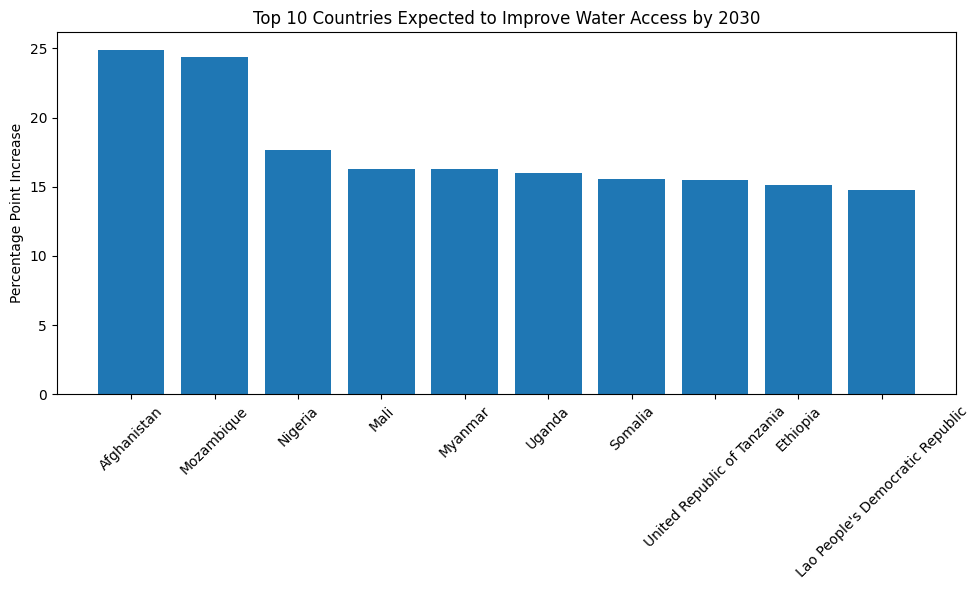

In [ ]:
# ==========================================================
# WATER ACCESS PROJECTION TO 2030
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ----------------------------------------------------------
# 1. LOAD DATASETS
# ----------------------------------------------------------

water_hist = pd.read_csv("Estimates of the use of water (2000-2020).csv")
# Fix: Re-add sep=';' for water_2020 to correctly parse the semicolon-separated values
water_2020 = pd.read_csv("Estimates on the use of water (2020).csv", sep=';')
regions = pd.read_csv("Regions.csv")

# ----------------------------------------------------------
# 2. INSPECT COLUMN NAMES
# ----------------------------------------------------------

print("Historical Data Columns:")
print(water_hist.columns.tolist())

print("\n2020 Data Columns:")
print(water_2020.columns.tolist())

print("\nRegion Columns:")
print(regions.columns.tolist())

# ----------------------------------------------------------
# 3. MERGE DATASETS
# ----------------------------------------------------------

# Fix: Change country_col to 'name' as it's the common identifier
country_col = "name"  # Changed from "iso3" to "name"

merged = (
    water_2020
    .merge(regions, on=country_col, how="left")
)

print("\nMerged shape:", merged.shape)

# ----------------------------------------------------------
# 4. EXTRACT BASIC WATER ACCESS SERIES
# ----------------------------------------------------------

# Find yearly columns automatically
water_cols = [
    col for col in water_hist.columns
    if "wat_bas_n" in col.lower()
]

print("\nWater coverage columns:")
print(water_cols)

# ----------------------------------------------------------
# 5. CREATE LONG FORMAT
# ----------------------------------------------------------

# Fix: Instead of melting incorrectly, select the existing 'year' column and the chosen water metric
long_df = water_hist[[country_col, 'year', water_cols[0]]].copy()
long_df = long_df.rename(columns={water_cols[0]: 'basic_water'})

# Ensure 'year' is treated as an integer after handling NaNs
long_df = long_df.dropna(subset=['year']).copy() # Drop rows where 'year' is NaN
long_df['year'] = long_df['year'].astype(int)

# Remove missing observations for the basic_water metric
long_df = long_df.dropna(subset=["basic_water"])

# ----------------------------------------------------------
# 6. FORECAST TO 2030
# ----------------------------------------------------------

forecast_results = []

countries = long_df[country_col].unique()

for country in countries:

    country_data = long_df[
        long_df[country_col] == country
    ].sort_values("year")

    # Fix: Relax the condition for number of data points for linear regression to 2
    if len(country_data) < 2:
        continue

    X = country_data[["year"]]
    y = country_data["basic_water"]

    model = LinearRegression()
    model.fit(X, y)

    prediction_2030 = model.predict([[2030]])[0]

    prediction_2030 = max(
        0,
        min(100, prediction_2030)
    )

    growth_per_year = model.coef_[0]

    # Fix: Use 'name' from country_col instead of 'iso3'
    forecast_results.append({
        "name": country,
        "coverage_2020": y.iloc[-1],
        "annual_change": growth_per_year,
        "projected_2030": prediction_2030
    })

forecast_df = pd.DataFrame(forecast_results)

# ----------------------------------------------------------
# 7. ADD REGION INFORMATION
# ----------------------------------------------------------

forecast_df = forecast_df.merge(
    regions,
    on="name", # Fix: Merge on 'name'
    how="left"
)

# ----------------------------------------------------------
# 8. CREATE INTERPRETATION CATEGORY
# ----------------------------------------------------------

def classify(value):
    if value >= 99:
        return "Universal Access"
    elif value >= 90:
        return "Very High Access"
    elif value >= 75:
        return "High Access"
    elif value >= 50:
        return "Moderate Access"
    else:
        return "Low Access"

forecast_df["2030_status"] = (
    forecast_df["projected_2030"]
    .apply(classify)
)

# ----------------------------------------------------------
# 9. SAVE RESULTS
# ----------------------------------------------------------

forecast_df.to_csv(
    "Water_Access_2030_Projection.csv",
    index=False
)

print("\nProjection file saved successfully.")

# ----------------------------------------------------------
# 10. TOP IMPROVERS BY 2030
# ----------------------------------------------------------

forecast_df["expected_improvement"] = (
    forecast_df["projected_2030"]
    - forecast_df["coverage_2020"]
)

top_improvers = (
    forecast_df
    .sort_values(
        "expected_improvement",
        ascending=False
    )
    .head(20)
)

print("\nTop 20 Expected Improvers:")
print(top_improvers[
    [
        "name", # Fix: Use 'name' instead of 'iso3'
        "coverage_2020",
        "projected_2030",
        "expected_improvement"
    ]
])

# ----------------------------------------------------------
# 11. REGIONAL PROJECTIONS
# ----------------------------------------------------------

regional_projection = (
    forecast_df
    .groupby("region")["projected_2030"] # Fix: Changed 'Region' to 'region'
    .mean()
    .reset_index()
    .sort_values(
        "projected_2030",
        ascending=False
    )
)

print("\nRegional Forecasts:")
print(regional_projection)

# ----------------------------------------------------------
# 12. VISUALIZATION
# ----------------------------------------------------------

import matplotlib.pyplot as plt

top10 = (
    forecast_df
    .sort_values(
        "expected_improvement",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(
    top10["name"], # Fix: Use 'name' instead of 'iso3'
    top10["expected_improvement"]
)
plt.title(
    "Top 10 Countries Expected to Improve Water Access by 2030"
)
plt.ylabel("Percentage Point Increase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
combined = pd.merge(
    forecast_df,
    predict_df,
    left_on="name",
    right_on="Country",
    how="inner"
)

In [ ]:
combined["Prediction_Difference"] = (
    combined["projected_2030"]
    - combined["Projected_2030"]
)

In [ ]:
combined["Expected_Improvement"] = (
    combined["projected_2030"]
    - combined["coverage_2020"]
)

In [ ]:
combined["Likely_Achieve_SDG"] = (
    combined["projected_2030"] >= 99
)

In [ ]:
def classify_risk(x):

    if x >= 99:
        return "On Track"

    elif x >= 90:
        return "Near Target"

    elif x >= 75:
        return "Moderate Risk"

    else:
        return "High Risk"

combined["Risk_Category"] = (
    combined["projected_2030"]
    .apply(classify_risk)
)

In [ ]:
combined[
    combined["Likely_Achieve_SDG"]
]

,name,coverage_2020,annual_change,projected_2030,region,2030_status,expected_improvement,Country,Region,Start_Year,...,Years_Passed,Annual_Velocity,Years_To_2030,Projected_2030,SDG_2030_Gap,SDG_Status,Prediction_Difference,Expected_Improvement,Likely_Achieve_SDG,Risk_Category
0,Curaçao,99.497752,0.0,99.497752,Latin America & Caribbean,Universal Access,0.0,Curaçao,Latin America & Caribbean,2015,...,2,0.0,13,99.497752,0.502248,Achieved Universal Access,0.0,0.0,True,On Track


In [ ]:
combined.sort_values(
    "SDG_2030_Gap",
    ascending=False
).head(20)

,name,coverage_2020,annual_change,projected_2030,region,2030_status,expected_improvement,Country,Region,Start_Year,...,Years_Passed,Annual_Velocity,Years_To_2030,Projected_2030,SDG_2030_Gap,SDG_Status,Prediction_Difference,Expected_Improvement,Likely_Achieve_SDG,Risk_Category
17,Eritrea,51.849720,0.384627,57.234493,Sub-Saharan Africa,Moderate Access,5.384773,Eritrea,Sub-Saharan Africa,2015,...,1,0.384627,14,57.234493,42.765507,Off Track (Too Slow),2.131628e-14,5.384773,False,High Risk
16,Equatorial Guinea,64.665816,0.243607,67.832710,Sub-Saharan Africa,Moderate Access,3.166894,Equatorial Guinea,Sub-Saharan Africa,2015,...,2,0.243607,13,67.832710,32.167290,Off Track (Too Slow),2.842171e-14,3.166894,False,High Risk
15,Comoros,80.210498,0.019624,80.426367,Sub-Saharan Africa,High Access,0.215869,Comoros,Sub-Saharan Africa,2015,...,4,0.019624,11,80.426367,19.573633,Off Track (Too Slow),0.000000e+00,0.215869,False,Moderate Risk
14,Micronesia (Federated States of),88.308157,0.000000,88.308157,East Asia & Pacific,High Access,0.000000,Micronesia (Federated States of),East Asia & Pacific,2015,...,4,0.000000,11,88.308157,11.691843,Stagnating or Regressing,0.000000e+00,0.000000,False,Moderate Risk
13,Channel Islands,94.150000,0.000000,94.150000,Europe & Central Asia,Very High Access,0.000000,Channel Islands,Europe & Central Asia,2015,...,2,0.000000,13,94.150000,5.850000,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
12,Turks and Caicos Islands,94.318182,0.000000,94.318182,Latin America & Caribbean,Very High Access,0.000000,Turks and Caicos Islands,Latin America & Caribbean,2015,...,3,0.000000,12,94.318182,5.681818,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
11,Saint Vincent and the Grenadines,95.145220,0.000000,95.145220,Latin America & Caribbean,Very High Access,0.000000,Saint Vincent and the Grenadines,Latin America & Caribbean,2015,...,3,0.000000,12,95.145220,4.854780,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
10,Sint Maarten (Dutch part),95.311179,0.000000,95.311179,Latin America & Caribbean,Very High Access,0.000000,Sint Maarten (Dutch part),Latin America & Caribbean,2015,...,2,0.000000,13,95.311179,4.688821,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
9,Dominica,95.420656,0.000000,95.420656,Latin America & Caribbean,Very High Access,0.000000,Dominica,Latin America & Caribbean,2015,...,2,0.000000,13,95.420656,4.579344,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
8,Grenada,95.628650,0.000000,95.628650,Latin America & Caribbean,Very High Access,0.000000,Grenada,Latin America & Caribbean,2015,...,2,0.000000,13,95.628650,4.371350,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target


In [ ]:
combined.groupby(
    "region"
)["projected_2030"].mean()

,projected_2030
region,
East Asia & Pacific,93.406128
Europe & Central Asia,94.150000
Latin America & Caribbean,96.752995
Sub-Saharan Africa,68.497857


In [ ]:
combined.sort_values(
    "annual_change",
    ascending=False
).head(20)

,name,coverage_2020,annual_change,projected_2030,region,2030_status,expected_improvement,Country,Region,Start_Year,...,Years_Passed,Annual_Velocity,Years_To_2030,Projected_2030,SDG_2030_Gap,SDG_Status,Prediction_Difference,Expected_Improvement,Likely_Achieve_SDG,Risk_Category
17,Eritrea,51.849720,0.384627,57.234493,Sub-Saharan Africa,Moderate Access,5.384773,Eritrea,Sub-Saharan Africa,2015,...,1,0.384627,14,57.234493,42.765507,Off Track (Too Slow),2.131628e-14,5.384773,False,High Risk
16,Equatorial Guinea,64.665816,0.243607,67.832710,Sub-Saharan Africa,Moderate Access,3.166894,Equatorial Guinea,Sub-Saharan Africa,2015,...,2,0.243607,13,67.832710,32.167290,Off Track (Too Slow),2.842171e-14,3.166894,False,High Risk
5,Seychelles,96.851747,0.150214,98.504099,East Asia & Pacific,Very High Access,1.652352,Seychelles,East Asia & Pacific,2015,...,4,0.150214,11,98.504099,1.495901,Off Track (Too Slow),-2.842171e-14,1.652352,False,Near Target
15,Comoros,80.210498,0.019624,80.426367,Sub-Saharan Africa,High Access,0.215869,Comoros,Sub-Saharan Africa,2015,...,4,0.019624,11,80.426367,19.573633,Off Track (Too Slow),0.000000e+00,0.215869,False,Moderate Risk
1,Bahamas,98.886961,0.000000,98.886961,Latin America & Caribbean,Very High Access,0.000000,Bahamas,Latin America & Caribbean,2015,...,4,0.000000,11,98.886961,1.113039,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
0,Curaçao,99.497752,0.000000,99.497752,Latin America & Caribbean,Universal Access,0.000000,Curaçao,Latin America & Caribbean,2015,...,2,0.000000,13,99.497752,0.502248,Achieved Universal Access,0.000000e+00,0.000000,True,On Track
6,Antigua and Barbuda,96.739186,0.000000,96.739186,Latin America & Caribbean,Very High Access,0.000000,Antigua and Barbuda,Latin America & Caribbean,2015,...,2,0.000000,13,96.739186,3.260814,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
2,Saint Kitts and Nevis,98.611854,0.000000,98.611854,Latin America & Caribbean,Very High Access,0.000000,Saint Kitts and Nevis,Latin America & Caribbean,2015,...,2,0.000000,13,98.611854,1.388146,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
3,Aruba,97.869023,0.000000,97.869023,Latin America & Caribbean,Very High Access,0.000000,Aruba,Latin America & Caribbean,2015,...,1,0.000000,14,97.869023,2.130977,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target
4,Anguilla,97.482274,0.000000,97.482274,Latin America & Caribbean,Very High Access,0.000000,Anguilla,Latin America & Caribbean,2015,...,2,0.000000,13,97.482274,2.517726,Stagnating or Regressing,0.000000e+00,0.000000,False,Near Target


In [ ]:
combined.to_csv('JMP_2030_Master_Combined_Analytics.csv', index=False)